In [2]:

import numpy as np
from pysbt import sbt

N    = 256
rmin = 2.0 / 1024 / 32
rmax = 30
rr   = np.logspace(np.log10(rmin), np.log10(rmax), N, endpoint=True)
beta = 2
f1   = 0.5*beta**3 *np.exp(-beta*rr)

ss = sbt(rr)                                        # init SBT
g1 = ss.run(f1, direction=1, norm=False) 

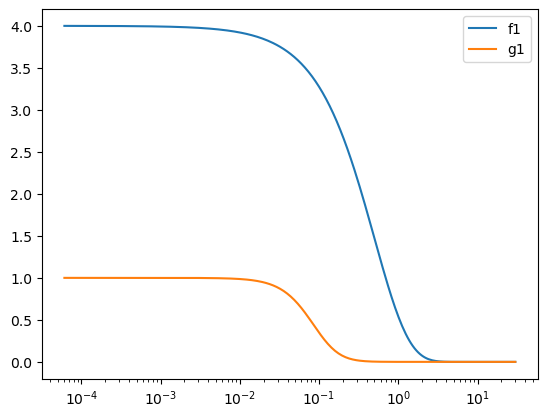

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rr, f1, label='f1')
plt.plot(rr, g1, label='g1')
plt.xscale('log')
plt.legend()
plt.show()

In [4]:
import Boris_SBT_code as BSBT

# def constructGridAndNorms(R, N, ell):
#     # TODO: add other boundary conditions
#     roots = rootsSphericalBesselFunctions(ell+1, N)
#     qln = roots[ell, :]
#     kln_nodes = qln / R
#     cln_norms = np.sqrt(2*np.pi) / R**3 / spherical_jn(ell+1, qln)**2.
#     return kln_nodes, cln_norms


# def forwardDiscreteSphericalBesselTransform(f_r, r_grid, ell,
#                                             kln_nodes, cln_norms):
#     R = r_grid[-1]
#     f_l_kln = continuousSphericalBesselTransform(f_r, r_grid, kln_nodes, ell)
#     return f_l_kln


R = 30
N = 100
ell = 0

kln_nodes, cln_norms = BSBT.constructGridAndNorms(R, N, ell)

r = np.logspace(0.01, np.log10(R), 1000)
f_r = np.exp(-r**2 / 2)

f_l_kln = BSBT.forwardDiscreteSphericalBesselTransform(f_r, r, ell, kln_nodes, cln_norms)

print(f_l_kln.shape)

(100,)


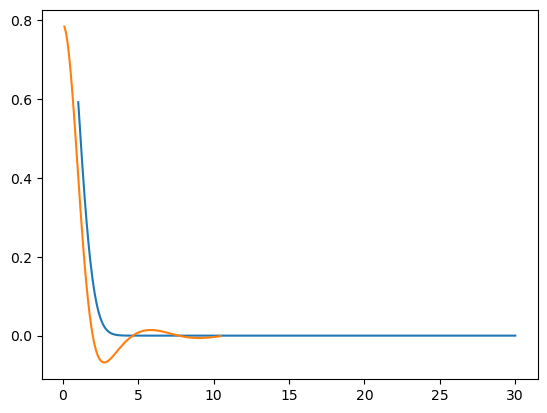

In [11]:
plt.plot(r, f_r, label='f_r')
plt.plot(kln_nodes,  f_l_kln, label='f_l_kln')
plt.show()